## Step 1: Loading the Dataset

The dataset is the Fake and Real News Dataset by Clément Bisaillon on Kaggle ([link](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset)). It has two files, `Fake.csv` and `True.csv`, each with the columns `title`, `text`, `subject`, and `date`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
path = '/content/drive/MyDrive/Classroom/'

import os
os.listdir(path)

['Applied physics SE SE',
 'CS G',
 'BS CS Section G G',
 'NUCS Buddy Program',
 'True.csv',
 'Fake.csv']

In [5]:
import pandas as pd

fake = pd.read_csv(path + 'Fake.csv')
true = pd.read_csv(path + 'True.csv')

print("Fake shape:", fake.shape)
print("True shape:", true.shape)

Fake shape: (23481, 4)
True shape: (21417, 4)


### Inspecting the Data

A quick look at the rows, columns and data types of each file.

In [6]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [8]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [9]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


## Step 2: Combining and Labelling

The two files are labelled (1 = fake, 0 = real), merged into one dataset, and shuffled.

In [10]:
# 1 = fake, 0 = real
fake['label'] = 1
true['label'] = 0

In [11]:
data = pd.concat([fake, true], ignore_index=True)
print("Combined shape:", data.shape)

Combined shape: (44898, 5)


In [12]:
# shuffle so classes are mixed
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


## Step 3: Descriptive Statistics

Checking class balance, subjects, and article length.

In [13]:
print(data['label'].value_counts())
print(data['label'].value_counts(normalize=True))

label
1    23481
0    21417
Name: count, dtype: int64
label
1    0.522985
0    0.477015
Name: proportion, dtype: float64


In [14]:
print(data['subject'].value_counts())

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


In [15]:
data['word_count'] = data['text'].apply(lambda t: len(t.split()))
print(data['word_count'].describe())

count    44898.000000
mean       405.282284
std        351.265595
min          0.000000
25%        203.000000
50%        362.000000
75%        513.000000
max       8135.000000
Name: word_count, dtype: float64


In [16]:
print("Articles with 0 words:", (data['word_count'] == 0).sum())

Articles with 0 words: 631


### Visualising the Dataset

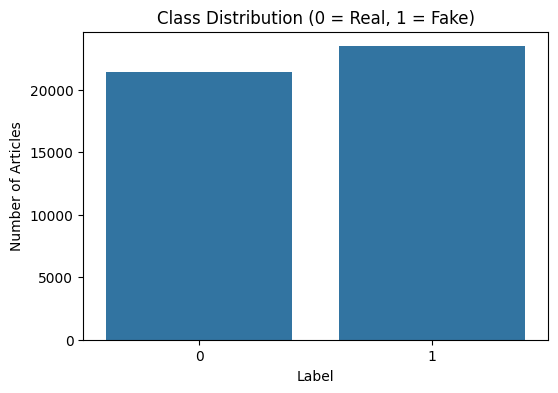

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data)
plt.title('Class Distribution (0 = Real, 1 = Fake)')
plt.xlabel('Label')
plt.ylabel('Number of Articles')
plt.show()

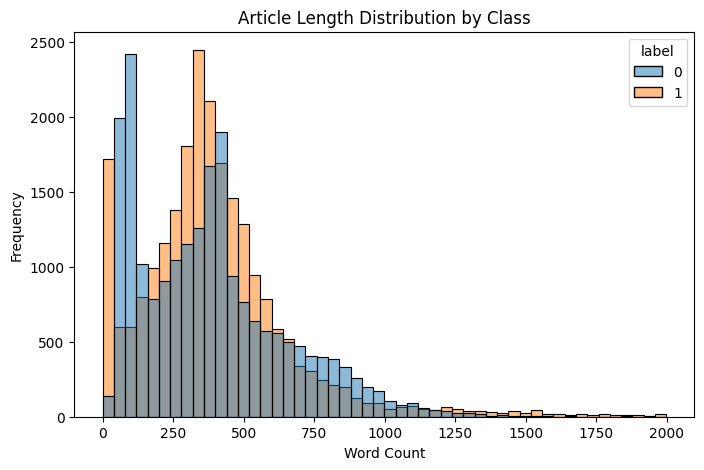

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data[data['word_count'] < 2000],
             x='word_count', hue='label', bins=50)
plt.title('Article Length Distribution by Class')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

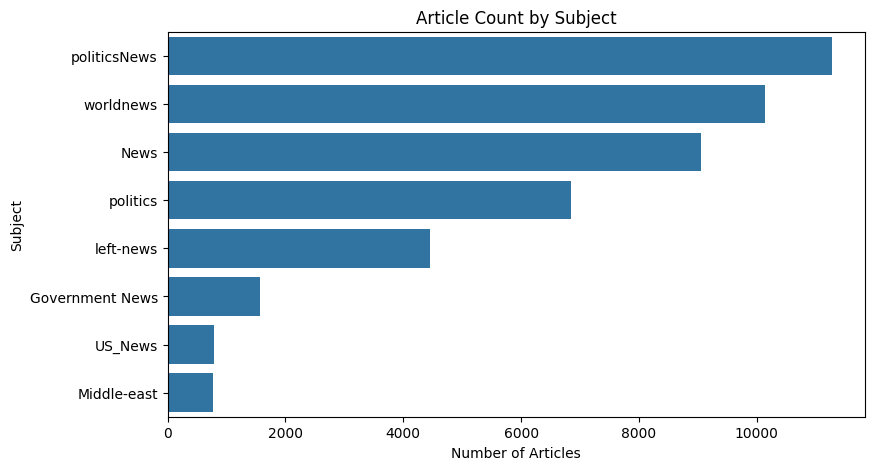

In [19]:
plt.figure(figsize=(9, 5))
sns.countplot(y='subject', data=data,
              order=data['subject'].value_counts().index)
plt.title('Article Count by Subject')
plt.xlabel('Number of Articles')
plt.ylabel('Subject')
plt.show()

## Step 4: Text Preprocessing

Cleaning the text: lowercasing, removing URLs, numbers and punctuation, tokenising, removing stopwords, and lemmatising.

In [20]:
# drop empty articles
data = data[data['word_count'] > 0].reset_index(drop=True)
print("Shape after dropping empties:", data.shape)

Shape after dropping empties: (44267, 6)


In [21]:
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [22]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                                        # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)                 # remove URLs
    text = re.sub(r'\d+', '', text)                            # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)                               # tokenise
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]  # stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]         # lemmatise
    return ' '.join(tokens)

In [23]:
print("BEFORE:\n", data['text'][0][:300])
print("\nAFTER:\n", clean_text(data['text'][0])[:300])

BEFORE:
 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on Pres

AFTER:
 st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement th circuit court 


In [24]:
data['clean_text'] = data['text'].apply(clean_text)
data[['text', 'clean_text']].head()

,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",st century wire say ben stein reputable profes...
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington reuters u president donald trump re...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,reuters puerto rico governor ricardo rossello ...
3,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrassed country accide...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland reuters u presidential candid...


In [25]:
raw_words = set(' '.join(data['text']).lower().split())
clean_words = set(' '.join(data['clean_text']).split())

print("Unique words before cleaning:", len(raw_words))
print("Unique words after cleaning:", len(clean_words))

Unique words before cleaning: 362593
Unique words after cleaning: 199011


## Step 5: Feature Extraction (TF-IDF)

The data is split into train and test sets, then TF-IDF is fitted on the training data only and applied to both.

In [26]:
X = data['clean_text']
y = data['label']

from sklearn.model_selection import train_test_split

# 80/20 split, stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 35413
Test size: 8854


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# unigrams + bigrams, top 5000 terms, ignore very rare words
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)

# fit on train only, then transform both sets
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (35413, 5000)
Test TF-IDF shape: (8854, 5000)


In [28]:
print(vectorizer.get_feature_names_out()[:20])

['abandon' 'abandoned' 'abbas' 'abc' 'abc news' 'abdullah' 'abe' 'abedin'
 'ability' 'able' 'abortion' 'abroad' 'absence' 'absolute' 'absolutely'
 'abu' 'abuse' 'academic' 'academy' 'accept']


## Step 6: Rule-Based Classifier

A simple lexicon-based baseline that flags articles containing sensational keywords.

In [29]:
# lexicon of sensational words often seen in fake news
fake_lexicon = [
    'shocking', 'unbelievable', 'breaking', 'secret', 'exposed',
    'outrageous', 'scandal', 'conspiracy', 'hoax', 'shocked',
    'slams', 'destroys', 'watch', 'viral', 'bombshell',
    'insane', 'terrifying', 'disgusting', 'wow', 'must see'
]

def rule_based_predict(text, threshold=1):
    count = sum(1 for word in fake_lexicon if word in text.split())
    return 1 if count >= threshold else 0

In [30]:
rule_preds = X_test.apply(rule_based_predict)

from sklearn.metrics import accuracy_score, classification_report

print("Rule-based Accuracy:", accuracy_score(y_test, rule_preds))
print("\nClassification Report:\n", classification_report(y_test, rule_preds))

Rule-based Accuracy: 0.61847752428281

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.89      0.69      4283
           1       0.78      0.36      0.50      4571

    accuracy                           0.62      8854
   macro avg       0.67      0.63      0.59      8854
weighted avg       0.68      0.62      0.59      8854



## Step 7: Machine Learning Models

Three supervised models are trained on the TF-IDF features: Naive Bayes, Logistic Regression, and Random Forest.

In [31]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("\nClassification Report:\n", classification_report(y_test, nb_preds))

Naive Bayes Accuracy: 0.9437542353738423

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      4283
           1       0.94      0.95      0.95      4571

    accuracy                           0.94      8854
   macro avg       0.94      0.94      0.94      8854
weighted avg       0.94      0.94      0.94      8854



In [32]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("\nClassification Report:\n", classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 0.9873503501242377

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      4283
           1       0.99      0.98      0.99      4571

    accuracy                           0.99      8854
   macro avg       0.99      0.99      0.99      8854
weighted avg       0.99      0.99      0.99      8854



In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
rf_preds = rf_model.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.996611700926135

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      4283
           1       1.00      1.00      1.00      4571

    accuracy                           1.00      8854
   macro avg       1.00      1.00      1.00      8854
weighted avg       1.00      1.00      1.00      8854



## Step 8: Evaluation

Comparing all models using Accuracy, Precision, Recall, F1-score and ROC-AUC, followed by confusion matrices and word clouds.

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    'Rule-based': rule_preds,
    'Naive Bayes': nb_preds,
    'Logistic Regression': lr_preds,
    'Random Forest': rf_preds
}

comparison = []
for name, preds in results.items():
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-score': f1_score(y_test, preds)
    })

comparison_df = pd.DataFrame(comparison).round(4)
print(comparison_df)

                 Model  Accuracy  Precision  Recall  F1-score
0           Rule-based    0.6185     0.7804  0.3632    0.4957
1          Naive Bayes    0.9438     0.9438  0.9475    0.9456
2  Logistic Regression    0.9874     0.9918  0.9836    0.9877
3        Random Forest    0.9966     0.9982  0.9952    0.9967


In [35]:
from sklearn.metrics import roc_auc_score, roc_curve

# probability of the positive class (fake) for each model
nb_proba = nb_model.predict_proba(X_test_tfidf)[:, 1]
lr_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]
rf_proba = rf_model.predict_proba(X_test_tfidf)[:, 1]

print("Naive Bayes ROC-AUC:", round(roc_auc_score(y_test, nb_proba), 4))
print("Logistic Regression ROC-AUC:", round(roc_auc_score(y_test, lr_proba), 4))
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))

Naive Bayes ROC-AUC: 0.9841
Logistic Regression ROC-AUC: 0.9987
Random Forest ROC-AUC: 1.0


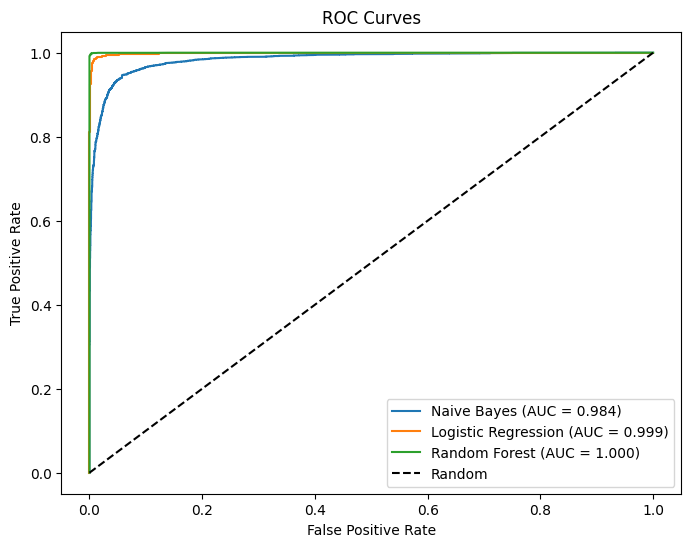

In [36]:
plt.figure(figsize=(8, 6))

for name, proba in [('Naive Bayes', nb_proba),
                    ('Logistic Regression', lr_proba),
                    ('Random Forest', rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

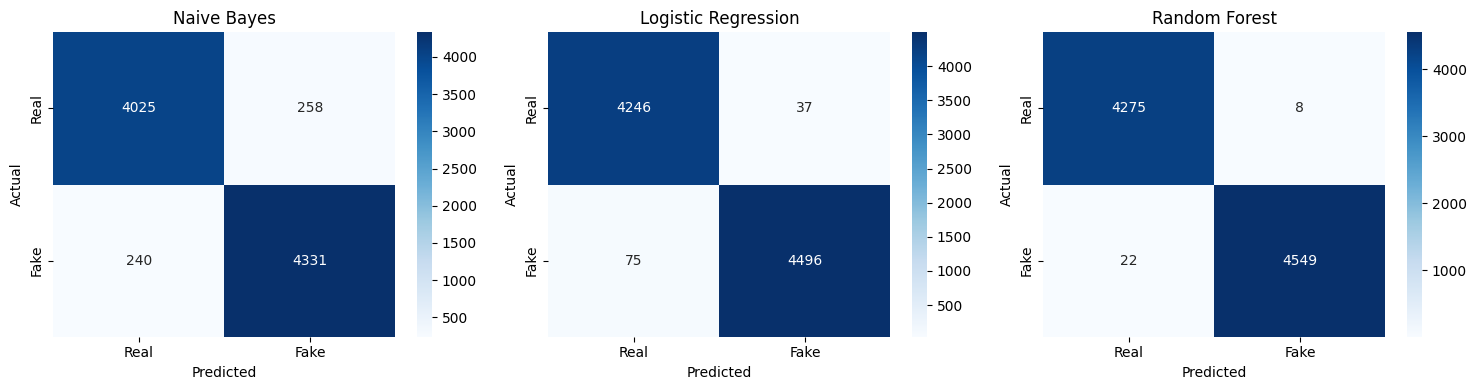

In [37]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_for_cm = [
    ('Naive Bayes', nb_preds),
    ('Logistic Regression', lr_preds),
    ('Random Forest', rf_preds)
]

for ax, (name, preds) in zip(axes, models_for_cm):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

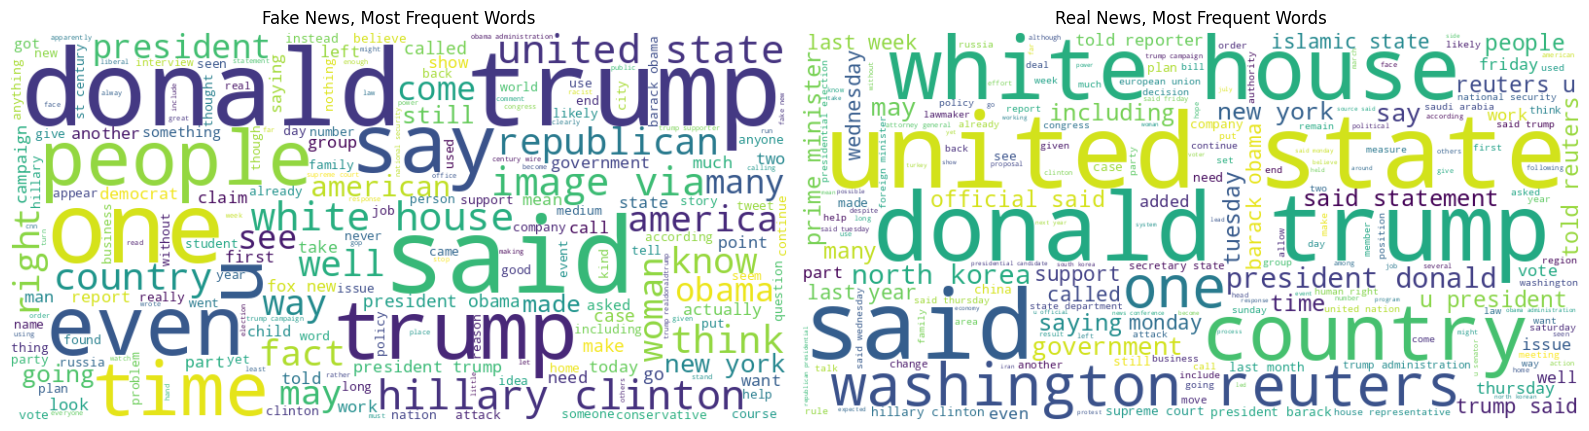

In [38]:
from wordcloud import WordCloud

fake_text = ' '.join(data[data['label'] == 1]['clean_text'])
real_text = ' '.join(data[data['label'] == 0]['clean_text'])

fake_cloud = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
real_cloud = WordCloud(width=800, height=400, background_color='white').generate(real_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(fake_cloud, interpolation='bilinear')
axes[0].set_title('Fake News, Most Frequent Words')
axes[0].axis('off')

axes[1].imshow(real_cloud, interpolation='bilinear')
axes[1].set_title('Real News, Most Frequent Words')
axes[1].axis('off')

plt.tight_layout()
plt.show()